In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes-dataset/Dataset of Diabetes .csv


In [2]:
dataset = pd.read_csv('/kaggle/input/diabetes-dataset/Dataset of Diabetes .csv')


In [3]:
le = LabelEncoder()

# Fit and transform the categorical data
dataset['Gender']= le.fit_transform(dataset['Gender'])
dataset['CLASS']= le.fit_transform(dataset['CLASS'])

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   int64  
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   int64  
dtypes: float64(8), int64(6)
memory usage: 109.5 KB


In [5]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000.0,340.500000,2.403977e+02,1.0,125.75,300.5,550.25,800.00
No_Pation,1000.0,270551.408000,3.380758e+06,123.0,24063.75,34395.5,45384.25,75435657.00
Gender,1000.0,0.567000,4.977537e-01,0.0,0.00,1.0,1.00,2.00
AGE,1000.0,53.528000,8.799241e+00,20.0,51.00,55.0,59.00,79.00
Urea,1000.0,5.124743,2.935165e+00,0.5,3.70,4.6,5.70,38.90
Cr,1000.0,68.943000,5.998475e+01,6.0,48.00,60.0,73.00,800.00
HbA1c,1000.0,8.281160,2.534003e+00,0.9,6.50,8.0,10.20,16.00
Chol,1000.0,4.862820,1.301738e+00,0.0,4.00,4.8,5.60,10.30
TG,1000.0,2.349610,1.401176e+00,0.3,1.50,2.0,2.90,13.80
HDL,1000.0,1.204750,6.604136e-01,0.2,0.90,1.1,1.30,9.90


In [6]:
print(dataset.isnull().sum())

ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64


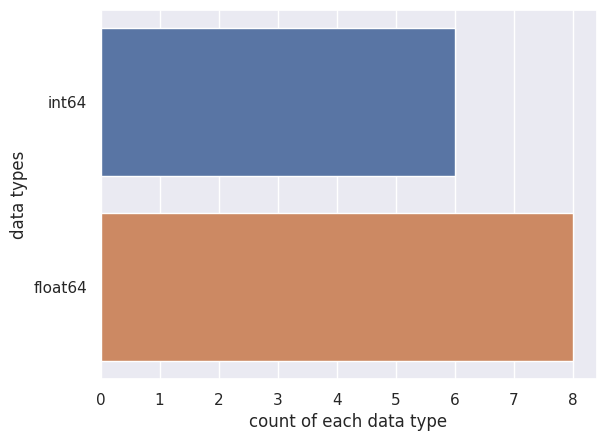

In [7]:
sns.countplot(y=dataset.dtypes ,data=dataset)
plt.xlabel("count of each data type")
plt.ylabel("data types")
plt.show()

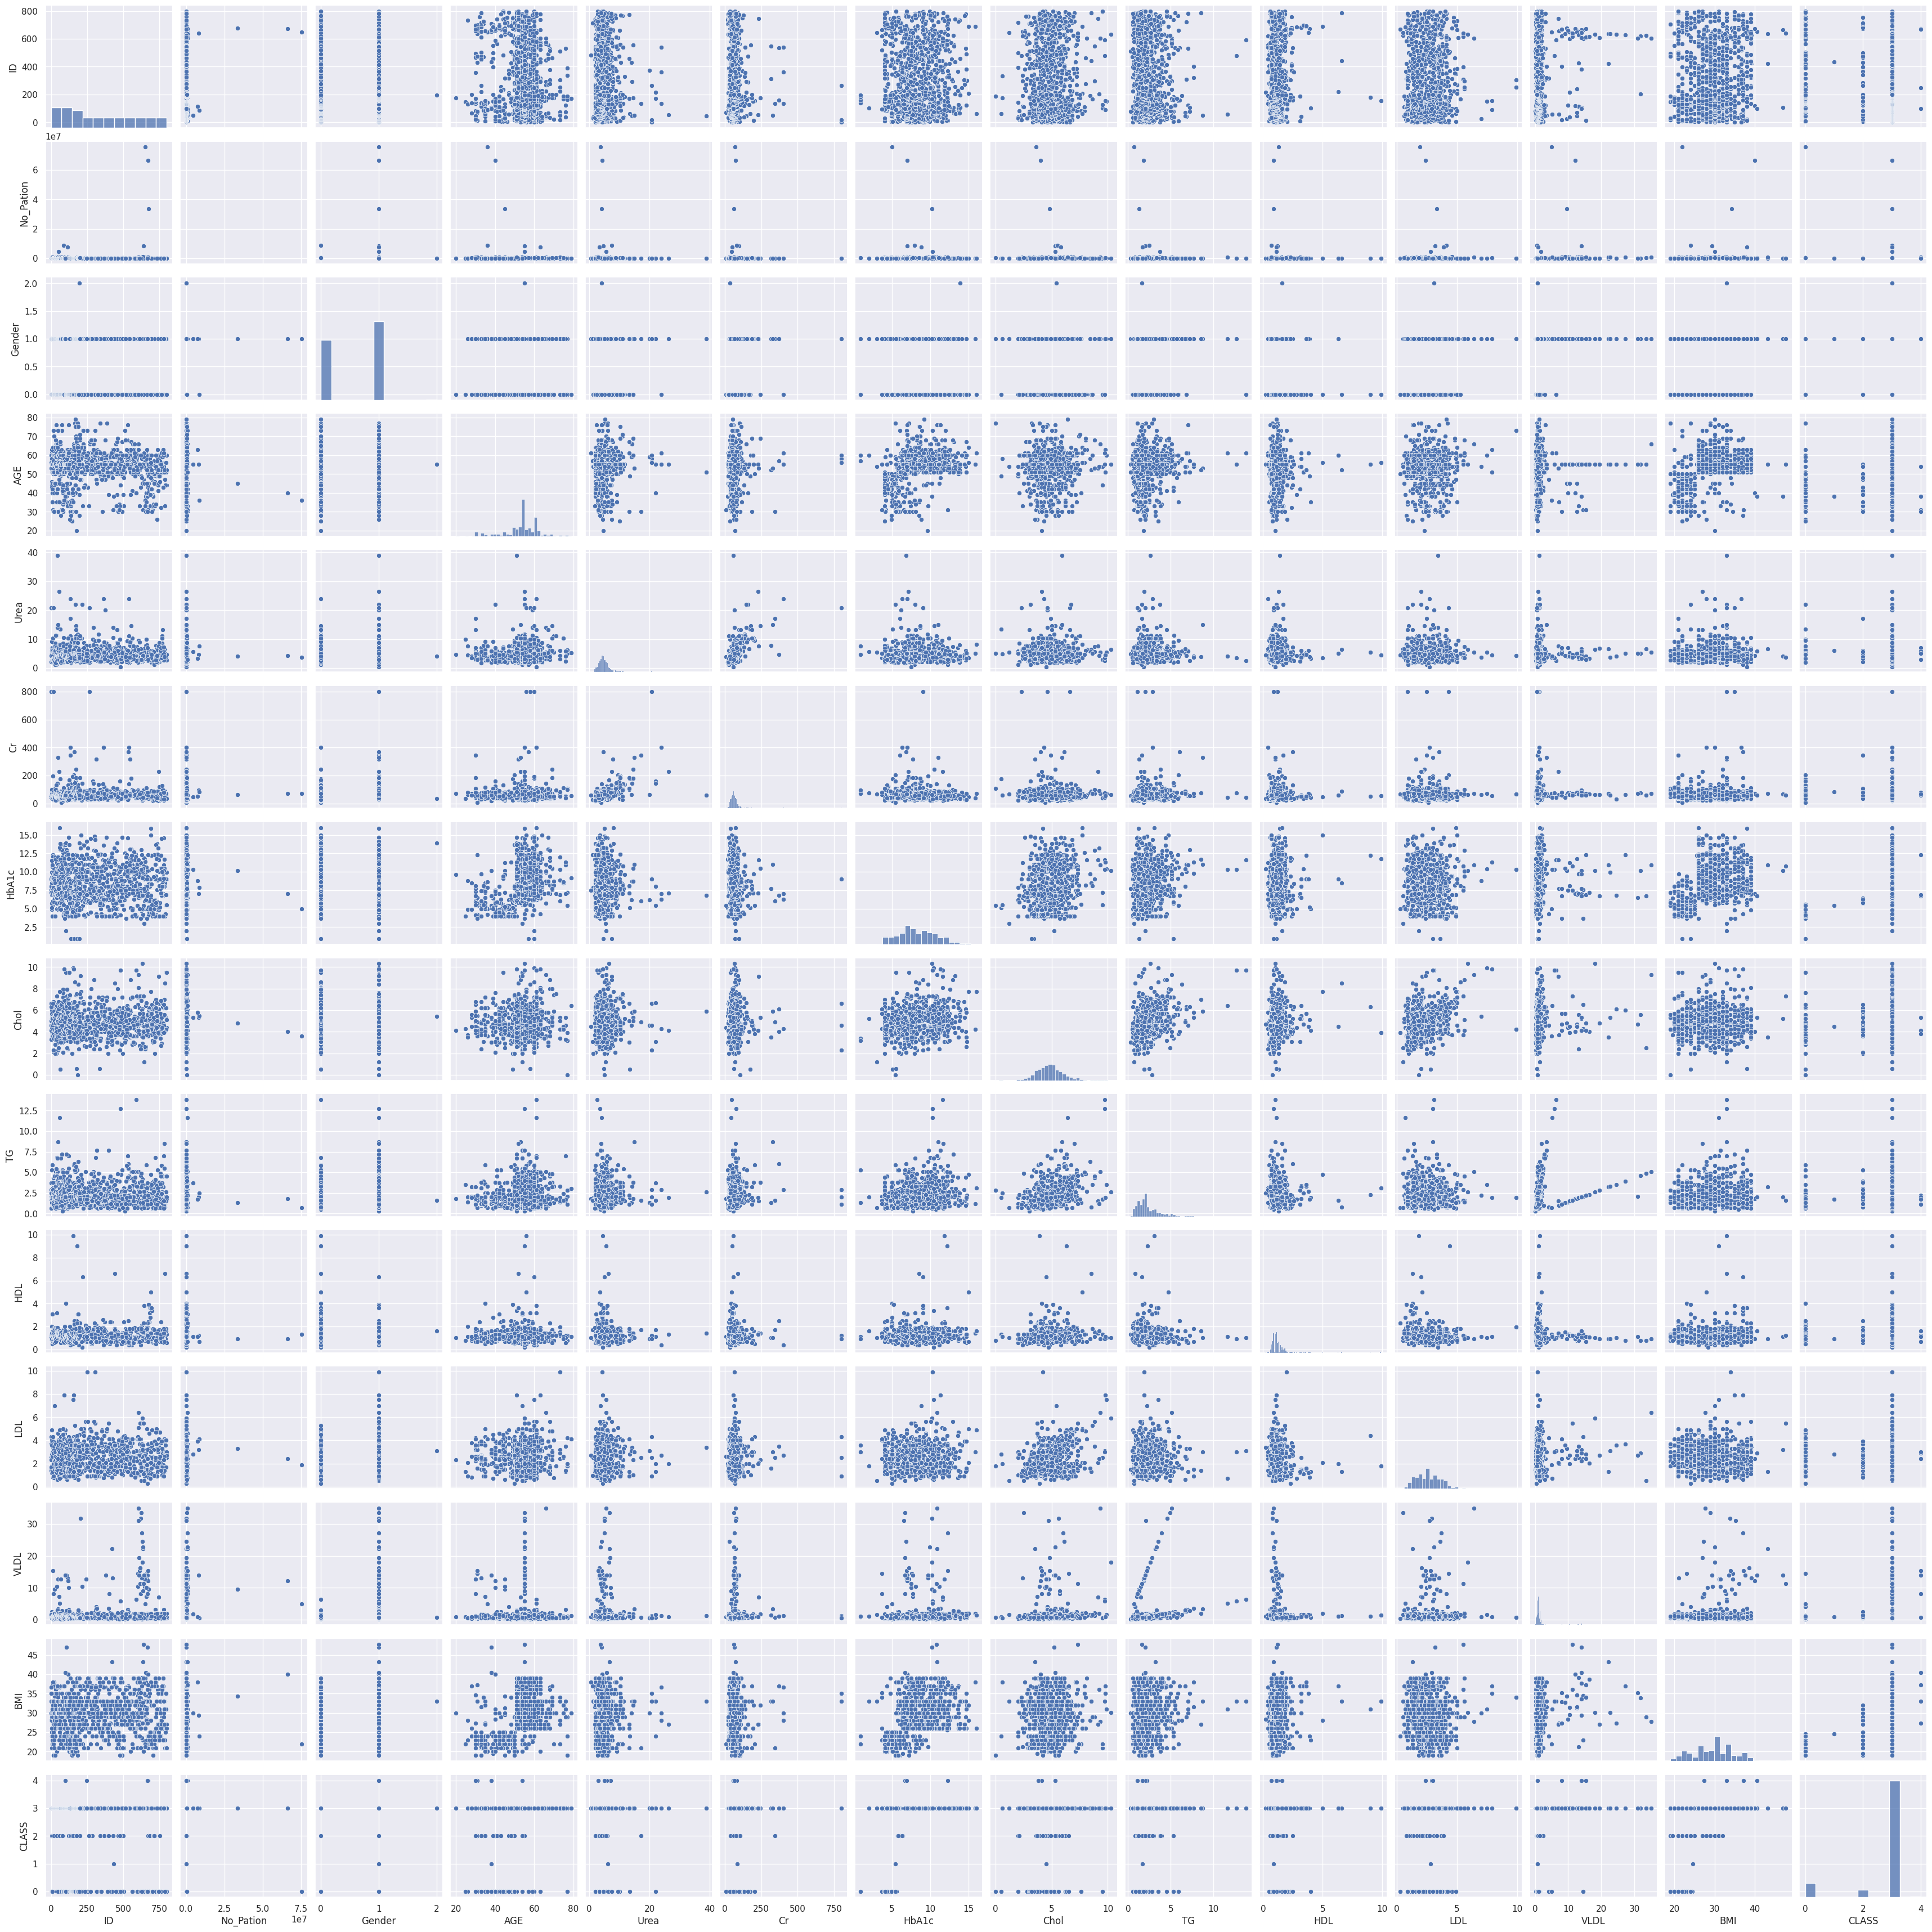

In [8]:
p=sns.pairplot(dataset)

In [9]:
dataset.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

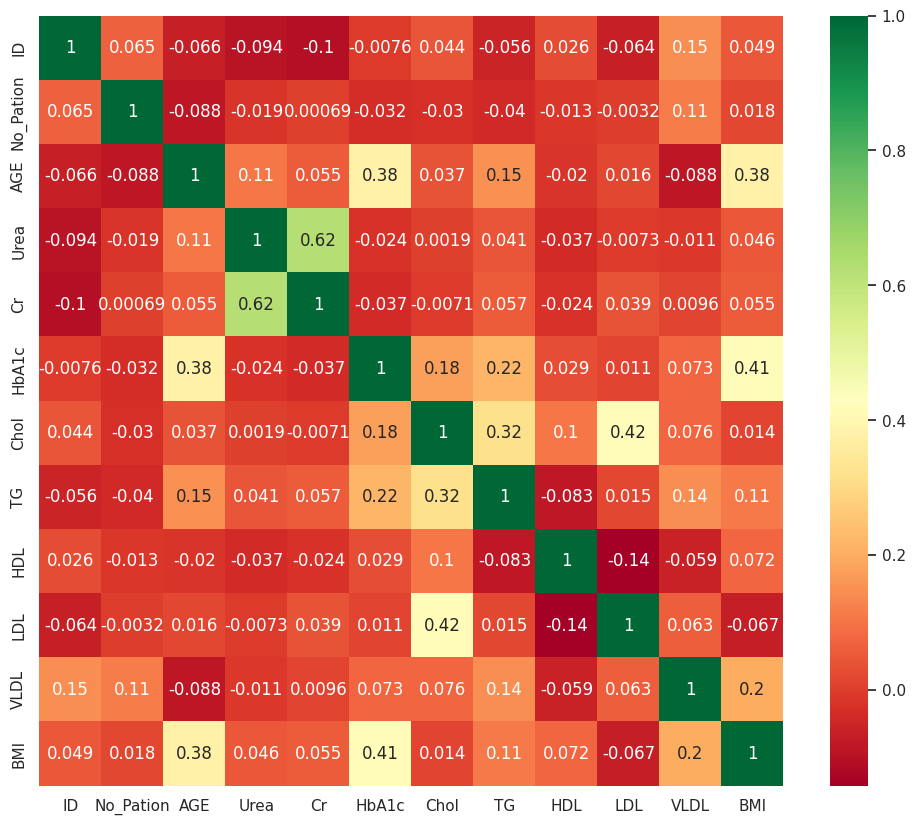

In [10]:
features = ['ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI']

selected = dataset[features]
plt.figure(figsize=(12,10)) 
p=sns.heatmap(selected.corr(), annot=True,cmap ='RdYlGn')

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(selected)
#sc.mean_
X =pd.DataFrame(sc.transform(selected), columns=features)
X

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0.672140,-0.074747,-0.401144,-0.144781,-0.382672,-1.334983,-0.509436,-1.035084,1.810756,-1.085457,-0.369958,-1.124622
1,1.641852,-0.069940,-3.130017,-0.212954,-0.115804,-1.334983,-0.893730,-0.678063,-0.158692,-0.457398,-0.342649,-1.326239
2,0.330868,-0.065869,-0.401144,-0.144781,-0.382672,-1.334983,-0.509436,-1.035084,1.810756,-1.085457,-0.369958,-1.124622
3,1.412950,-0.054126,-0.401144,-0.144781,-0.382672,-1.334983,-0.509436,-1.035084,1.810756,-1.085457,-0.369958,-1.124622
4,0.680463,-0.069939,-2.334096,0.673299,-0.382672,-1.334983,0.028576,-0.963680,-0.613180,-0.547121,-0.397267,-1.729472
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.584741,0.054384,1.986619,2.002680,0.467970,-0.505840,2.026906,-0.463850,-0.007196,-0.726566,-0.342649,0.085078
996,1.375493,0.179334,-2.561502,-0.724254,-0.149162,1.586758,-0.586295,-0.106828,-0.764676,-0.188229,3.699116,1.536719
997,1.367170,-0.054127,-2.675205,0.673299,0.201102,-0.624289,-0.586295,-0.892276,-0.007196,-0.188229,1.705543,-0.439125
998,-1.005088,-0.072963,-1.765581,0.230173,-0.165842,-0.624289,0.336011,-0.249637,0.598788,0.260385,3.316787,2.202054


In [12]:
y = dataset.CLASS

In [13]:
y

0      0
1      0
2      0
3      0
4      0
      ..
995    3
996    4
997    4
998    4
999    4
Name: CLASS, Length: 1000, dtype: int64

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=1/3,random_state=85)

In [15]:
from sklearn.neighbors import KNeighborsClassifier


test_scores = []
train_scores = []

for i in range(1,15):

    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)
    
    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

In [16]:
max_train_score = max(train_scores)
train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
print('Max train score {} % and k = {}'.format(max_train_score*100,list(map(lambda x: x+1, train_scores_ind))))

Max train score 100.0 % and k = [1]


In [17]:
max_test_score = max(test_scores)
test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
print('Max test score {} % and k = {}'.format(max_test_score*100,list(map(lambda x: x+1, test_scores_ind))))

Max test score 91.01796407185628 % and k = [9, 10]


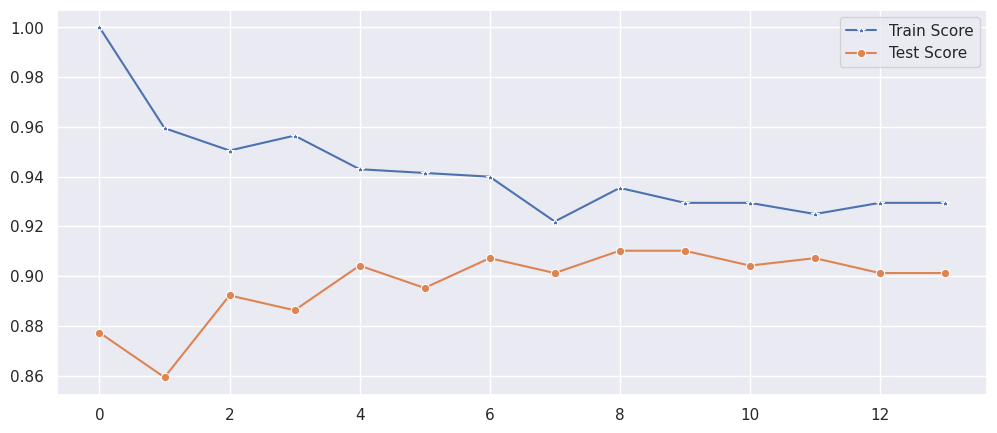

In [18]:
plt.figure(figsize=(12,5))
p = sns.lineplot(train_scores,marker='*',label='Train Score')
p = sns.lineplot(test_scores,marker='o',label='Test Score')

In [19]:
knn = KNeighborsClassifier(9)

knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.9101796407185628

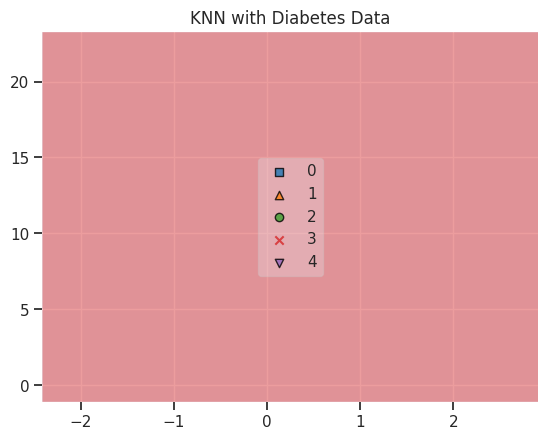

In [20]:
value = 200000
width = 200000
plot_decision_regions(X.values, y.values, clf=knn, legend=10, 
                      filler_feature_values={2: value, 3: value, 4: value, 5: value, 6: value, 7: value,8: value, 9: value, 10: value, 11: value},
                      filler_feature_ranges={2: width, 3: width, 4: width, 5: width, 6: width, 7: width,8: value, 9: value, 10: value, 11: value},
                      X_highlight=X_test.values)

# Adding axes annotations
#plt.xlabel('sepal length [cm]')
#plt.ylabel('petal length [cm]')
plt.title('KNN with Diabetes Data')
plt.show()

In [21]:


#import confusion_matrix
from sklearn.metrics import confusion_matrix
#let us get the predictions using the classifier we had fit above
y_pred = knn.predict(X_test)
confusion_matrix(y_test,y_pred)
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)



Predicted,0,2,3,All
True,,,,
0,21,1,7,29
2,5,4,8,17
3,5,3,279,287
4,0,0,1,1
All,31,8,295,334


Text(0.5, 19.049999999999997, 'Predicted label')

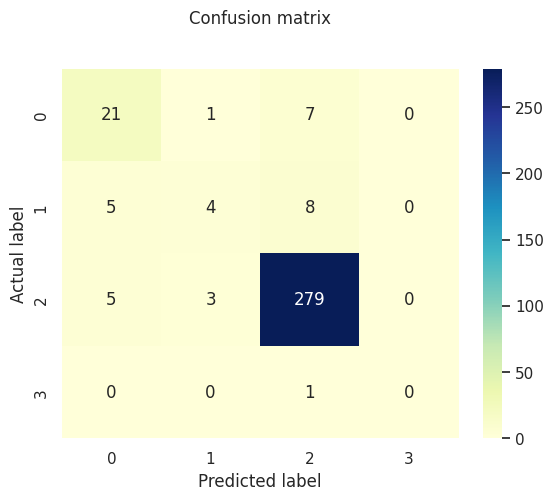

In [22]:
y_pred = knn.predict(X_test)
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [23]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.72      0.70        29
           2       0.50      0.24      0.32        17
           3       0.95      0.97      0.96       287
           4       0.00      0.00      0.00         1

    accuracy                           0.91       334
   macro avg       0.53      0.48      0.49       334
weighted avg       0.90      0.91      0.90       334



In [24]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV
#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))


Best Score:0.8880000000000001
Best Parameters: {'n_neighbors': 30}
